# Sylhet Air Quality vs Tree Cover (NDVI) — Full Project

**Research question:** To what extent does vegetation cover (NDVI, a satellite-based proxy for tree/plant cover) influence ground-level PM2.5 air pollution in Sylhet, Bangladesh, once weather and seasonal effects are accounted for?

**How this notebook is organized (Tasks 1–9):**
1. Collect PM2.5 + weather data
2. Collect solar radiation + soil moisture data
3. Collect real satellite NDVI (tree/vegetation cover) data
4. Merge everything into one dataset
5. Explore the data (EDA) — trends, seasonality, correlations
6. Engineer features for modeling
7. Train and compare prediction models
8. Interpret the models (which features matter, and why)
9. Summarize findings for a research paper

Run the cells **top to bottom, in order** — later sections depend on files saved by earlier ones.

## Glossary (read this first if you're new to ML)

- **NDVI** — Normalized Difference Vegetation Index. A number from -1 to 1 calculated from satellite images; higher values mean more/healthier green vegetation. We use it as our tree-cover proxy.
- **PM2.5** — Fine particulate matter pollution (particles smaller than 2.5 micrometers). Our target variable — the thing we're trying to explain/predict.
- **Feature** — An input variable we give the model (e.g., temperature, NDVI) so it can predict the target (PM2.5).
- **Train/test split** — We train the model on older data and test it on newer, unseen data, to check it can generalize rather than just memorize.
- **Data leakage** — Accidentally letting the model "see" information it shouldn't have access to at prediction time (like future data, or the answer itself). It makes results look better than they really are.
- **RMSE / MAE** — Root Mean Squared Error / Mean Absolute Error. Both measure how far off predictions are from actual values, in the same units as PM2.5 (µg/m³). Lower is better.
- **R² (R-squared)** — A score from roughly 0 to 1 showing how much of the variation in PM2.5 the model explains. 1 = perfect, 0 = no better than guessing the average.
- **p-value** — In a statistical test, the probability of seeing a result this strong just by random chance. Below 0.05 is usually considered "probably not random."
- **SHAP value** — A method that explains *how much* and in *which direction* each feature pushed an individual prediction up or down. Better than basic "feature importance" because it also shows direction.

## Task 1: Collect PM2.5 and weather data (Open-Meteo)

**What this does:** downloads hourly PM2.5, temperature, and humidity for Sylhet from the Open-Meteo API, then averages each day into a single daily value.

**Why:** PM2.5 is our target — the thing we want to explain. Temperature and humidity are common physical drivers of air quality (e.g., rain clears the air; still, dry air lets pollution build up), so we collect them as candidate features.

In [ ]:
import pandas as pd
import requests
import time
import numpy as np

# --- Study area and date range (used throughout the whole notebook) ---
LATITUDE = 24.8990
LONGITUDE = 91.8687
START_DATE = "2022-08-01"
END_DATE = "2026-05-31"
TIMEZONE = "Asia/Dhaka"

MAX_RETRIES = 5
RETRY_DELAY_SECONDS = 10

def fetch_json_with_retry(url, params, max_retries=MAX_RETRIES, delay=RETRY_DELAY_SECONDS):
    """Fetches JSON from a URL, retrying on timeout/network errors."""
    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, timeout=30)
            response.raise_for_status()
            return response.json()
        except requests.exceptions.RequestException as e:
            print(f"Attempt {attempt + 1}/{max_retries} failed: {e}. Retrying in {delay}s...")
            time.sleep(delay)
    raise Exception(f"Failed to fetch data from {url} after {max_retries} attempts.")

In [ ]:
print("Fetching PM2.5 data from Open-Meteo Air Quality API...")
aq_params = {
    "latitude": LATITUDE, "longitude": LONGITUDE,
    "start_date": START_DATE, "end_date": END_DATE,
    "hourly": ["pm2_5"], "timezone": TIMEZONE
}
aq_data = fetch_json_with_retry("https://air-quality-api.open-meteo.com/v1/air-quality", aq_params)
print("PM2.5 data fetched successfully.")

print("\nFetching temperature and humidity data from Open-Meteo Weather Archive API...")
weather_end_date = min(pd.to_datetime(END_DATE), pd.to_datetime('today')).strftime('%Y-%m-%d')
weather_params = {
    "latitude": LATITUDE, "longitude": LONGITUDE,
    "start_date": START_DATE, "end_date": weather_end_date,
    "hourly": "temperature_2m,relative_humidity_2m", "timezone": TIMEZONE
}
weather_data = fetch_json_with_retry("https://archive-api.open-meteo.com/v1/archive", weather_params)
print("Weather data fetched successfully.")

Fetching PM2.5 data from Open-Meteo Air Quality API...
PM2.5 data fetched successfully.

Fetching temperature and humidity data from Open-Meteo Weather Archive API...
Weather data fetched successfully.


In [ ]:
# Convert hourly data to daily averages, and flag any day with poor hourly coverage
HOURLY_COVERAGE_THRESHOLD = 0.5  # need at least 50% of the 24 hours to trust the daily average

def hourly_to_daily(json_data, value_cols):
    df = pd.DataFrame(json_data['hourly'])
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')
    coverage = df.groupby(df.index.date)[value_cols].count() / 24
    coverage.index = pd.to_datetime(coverage.index)
    daily = df.resample('D').mean().reset_index().rename(columns={'time': 'date'})
    for col in value_cols:
        daily[f'{col}_low_coverage_flag'] = (coverage[col].values < HOURLY_COVERAGE_THRESHOLD).astype(int)
    return daily

df_aq_daily = hourly_to_daily(aq_data, ['pm2_5'])
df_weather_daily = hourly_to_daily(weather_data, ['temperature_2m', 'relative_humidity_2m'])

df_daily = pd.merge(df_aq_daily, df_weather_daily, on='date', how='outer')

print(f"Fetched {df_daily['date'].nunique()} days: {df_daily['date'].min().date()} to {df_daily['date'].max().date()}")
print(f"Days with low PM2.5 coverage: {df_daily['pm2_5_low_coverage_flag'].sum()}")

df_daily.to_csv("sylhet_aqi_weather_extended.csv", index=False)
print("Saved to sylhet_aqi_weather_extended.csv")
df_daily.head()

Fetched 1400 days: 2022-08-01 to 2026-05-31
Days with low PM2.5 coverage: 3
Saved to sylhet_aqi_weather_extended.csv


,date,pm2_5,pm2_5_low_coverage_flag,temperature_2m,relative_humidity_2m,temperature_2m_low_coverage_flag,relative_humidity_2m_low_coverage_flag
0,2022-08-01,NaN,1,26.637500,90.250000,0,0
1,2022-08-02,NaN,1,28.079167,87.791667,0,0
2,2022-08-03,NaN,1,28.308333,87.833333,0,0
3,2022-08-04,14.850000,0,28.595833,84.958333,0,0
4,2022-08-05,15.820833,0,29.337500,82.958333,0,0


## Task 2: Collect solar radiation and soil moisture (NASA POWER)

**What this does:** downloads daily solar radiation and soil moisture for the same location and date range from NASA's POWER API.

**Why:** Solar radiation affects how pollutants form and disperse in the atmosphere; soil moisture is a useful cross-check against NDVI, since dry soil often coincides with less green vegetation.

In [ ]:
NASA_START = pd.to_datetime(START_DATE).strftime('%Y%m%d')
NASA_END = pd.to_datetime(END_DATE).strftime('%Y%m%d')
nasa_url = (
    "https://power.larc.nasa.gov/api/temporal/daily/point"
    f"?parameters=ALLSKY_SFC_SW_DWN,GWETPROF&community=RE"
    f"&longitude={LONGITUDE}&latitude={LATITUDE}&start={NASA_START}&end={NASA_END}&format=JSON"
)

print("Fetching NASA POWER data (solar radiation, soil moisture)...")
nasa_data = fetch_json_with_retry(nasa_url, params={})

df_solar = pd.DataFrame.from_dict(nasa_data['properties']['parameter']['ALLSKY_SFC_SW_DWN'], orient='index', columns=['solar_radiation'])
df_soil = pd.DataFrame.from_dict(nasa_data['properties']['parameter']['GWETPROF'], orient='index', columns=['soil_moisture'])
df_nasa = df_solar.join(df_soil)
df_nasa.index = pd.to_datetime(df_nasa.index, format='%Y%m%d')
df_nasa.index.name = 'date'

# NASA POWER uses -999.0 to mean "missing" -- replace with NaN, then interpolate over time
n_missing = (df_nasa == -999.0).sum().sum()
df_nasa = df_nasa.replace(-999.0, np.nan).interpolate(method='time', limit_direction='both')
print(f"Replaced and interpolated {n_missing} missing NASA POWER values.")

df_nasa.to_csv('sylhet_nasa_solar_soil.csv')
print("Saved to sylhet_nasa_solar_soil.csv")
df_nasa.head()

Fetching NASA POWER data (solar radiation, soil moisture)...
Replaced and interpolated 0 missing NASA POWER values.
Saved to sylhet_nasa_solar_soil.csv


,solar_radiation,soil_moisture
date,,
2022-08-01,3.1639,0.97
2022-08-02,4.0898,0.97
2022-08-03,4.8216,0.96
2022-08-04,4.1498,0.96
2022-08-05,4.8533,0.96


## Task 3: Collect real NDVI via Google Earth Engine

**What this does:** pulls *real* satellite vegetation data (NDVI) around Sylhet from two satellite programs — Sentinel-2 (detailed, but often blocked by clouds) and MODIS (coarser, but more reliably continuous) — and combines them into one usable daily series.

**Why this matters:** this replaces any made-up/simulated NDVI. Since our whole research question is about *real* vegetation trends, this has to be actual satellite measurement, not a guess.

**Before running this cell:** you need a free Google Earth Engine account and a Google Cloud project ID with Earth Engine enabled. Replace `GEE_PROJECT_ID` below with your own.

In [ ]:
import ee

print("Authenticating Google Earth Engine (a browser tab/prompt will ask you to log in)...")
ee.Authenticate()

GEE_PROJECT_ID = 'sacred-veld-505713-h5'  # <-- REPLACE with your own GEE Cloud project ID
ee.Initialize(project=GEE_PROJECT_ID)
print(f"Earth Engine initialized for project: {GEE_PROJECT_ID}")

# Define a 20km region around Sylhet -- a single point is too noisy to represent
# "regional tree cover", so we average NDVI across this whole area instead.
BUFFER_RADIUS_KM = 20
sylhet_point = ee.Geometry.Point(LONGITUDE, LATITUDE)
sylhet_region = sylhet_point.buffer(BUFFER_RADIUS_KM * 1000)
print(f"Study region: {BUFFER_RADIUS_KM}km buffer around Sylhet ({LATITUDE}, {LONGITUDE})")

Authenticating Google Earth Engine (a browser tab/prompt will ask you to log in)...
Earth Engine initialized for project: sacred-veld-505713-h5
Study region: 20km buffer around Sylhet (24.899, 91.8687)


### Sentinel-2 NDVI (detailed, but cloud-affected)

Sylhet gets heavy monsoon cloud cover, and clouds ruin satellite vegetation readings. So before computing NDVI, we mask out (remove) any cloudy pixels using Sentinel-2's built-in cloud-flag band (QA60).

In [ ]:
def mask_s2_clouds(image):
    """Removes cloudy/cirrus pixels using the QA60 quality band."""
    qa = image.select('QA60')
    cloud_bit, cirrus_bit = 1 << 10, 1 << 11
    mask = qa.bitwiseAnd(cloud_bit).eq(0).And(qa.bitwiseAnd(cirrus_bit).eq(0))
    return image.updateMask(mask).divide(10000).copyProperties(image, ['system:time_start'])

def add_ndvi(image):
    """NDVI = (Near-Infrared - Red) / (Near-Infrared + Red). Higher = more/healthier vegetation."""
    return image.addBands(image.normalizedDifference(['B8', 'B4']).rename('NDVI')).copyProperties(image, ['system:time_start'])

print("Collecting Sentinel-2 NDVI...")
s2_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                  .filterDate(START_DATE, pd.to_datetime(END_DATE) + pd.Timedelta(days=1))
                  .filterBounds(sylhet_region)
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 70)))
s2_ndvi = s2_collection.map(mask_s2_clouds).map(add_ndvi).select('NDVI')

def extract_s2(image):
    date = image.date().format('YYYY-MM-dd')
    mean_ndvi = image.reduceRegion(reducer=ee.Reducer.mean(), geometry=sylhet_region, scale=10, maxPixels=1e13).get('NDVI')
    return ee.Feature(None, {'date': date, 'NDVI_S2_raw': mean_ndvi})

s2_features = s2_ndvi.map(extract_s2).getInfo()
s2_df = pd.DataFrame([f['properties'] for f in s2_features['features']])
s2_df['date'] = pd.to_datetime(s2_df['date'])
s2_df = s2_df.set_index('date').sort_index()
# A satellite can pass over more than once on the same day -- average those into one value per day
s2_df = s2_df.groupby(s2_df.index).mean()

print(f"Sentinel-2: {len(s2_df)} daily observations (many days will be missing due to clouds -- that's expected).")
s2_df.head()

Sentinel-2: 185 daily observations (many days will be missing due to clouds -- that's expected).


,NDVI_S2_raw
date,
2022-08-14,0.286815
2022-08-19,0.129260
2022-08-24,0.284593
2022-08-29,0.105225
2022-09-08,0.373186


### MODIS NDVI (coarser resolution, but fills the gaps)

MODIS revisits every 16 days regardless of cloud cover, so we use it to fill in dates where Sentinel-2 has no usable data.

In [ ]:
print("Collecting MODIS MOD13Q1 NDVI...")
modis_collection = (ee.ImageCollection('MODIS/061/MOD13Q1')
                     .filterDate(START_DATE, pd.to_datetime(END_DATE) + pd.Timedelta(days=1))
                     .filterBounds(sylhet_region))

def extract_modis(image):
    date = image.date().format('YYYY-MM-dd')
    mean_ndvi = image.select('NDVI').divide(10000).reduceRegion(reducer=ee.Reducer.mean(), geometry=sylhet_region, scale=250).get('NDVI')
    return ee.Feature(None, {'date': date, 'NDVI_MODIS_raw': mean_ndvi})

modis_features = modis_collection.map(extract_modis).getInfo()
modis_df = pd.DataFrame([f['properties'] for f in modis_features['features']])
modis_df['date'] = pd.to_datetime(modis_df['date'])
modis_df = modis_df.set_index('date').sort_index()
modis_df = modis_df.groupby(modis_df.index).mean()

print(f"MODIS: {len(modis_df)} observations (16-day revisit, so fewer but more complete).")
modis_df.head()

MODIS: 88 observations (16-day revisit, so fewer but more complete).


,NDVI_MODIS_raw
date,
2022-08-13,0.448285
2022-08-29,0.529481
2022-09-14,0.602420
2022-09-30,0.592699
2022-10-16,0.631580


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Combine into one daily NDVI series

We build a full daily calendar, fill it with Sentinel-2 where available, fall back to MODIS where Sentinel-2 is missing, and interpolate (smoothly fill in) any days still missing. We keep a `NDVI_source_flag` column so we always know, later, which values are real satellite readings and which were estimated — this matters for being honest about data quality in a paper.

In [ ]:
full_date_range = pd.date_range(start=START_DATE, end=END_DATE, freq='D')
ndvi_combined = pd.DataFrame(index=full_date_range)
ndvi_combined.index.name = 'date'
ndvi_combined = ndvi_combined.merge(s2_df[['NDVI_S2_raw']], left_index=True, right_index=True, how='left')
ndvi_combined = ndvi_combined.merge(modis_df[['NDVI_MODIS_raw']], left_index=True, right_index=True, how='left')

# Prefer Sentinel-2 (higher resolution); fall back to MODIS where S2 is missing
ndvi_combined['NDVI_interpolated'] = ndvi_combined['NDVI_S2_raw'].fillna(ndvi_combined['NDVI_MODIS_raw'])

# 1 = real Sentinel-2 reading, 2 = real MODIS reading, 0 = filled in by interpolation
ndvi_combined['NDVI_source_flag'] = 0
ndvi_combined.loc[ndvi_combined['NDVI_S2_raw'].notna(), 'NDVI_source_flag'] = 1
ndvi_combined.loc[ndvi_combined['NDVI_S2_raw'].isna() & ndvi_combined['NDVI_MODIS_raw'].notna(), 'NDVI_source_flag'] = 2

# Fill remaining gaps with straight-line interpolation between known points
ndvi_combined['NDVI_interpolated'] = ndvi_combined['NDVI_interpolated'].interpolate(method='linear', limit_direction='both')

n_real = (ndvi_combined['NDVI_source_flag'] > 0).sum()
n_total = len(ndvi_combined)
print(f"Real satellite NDVI observations: {n_real} / {n_total} days ({n_real/n_total:.0%})")
print(f"Interpolated (estimated) days: {n_total - n_real} / {n_total} ({(n_total-n_real)/n_total:.0%})")
print("--> Keep this ratio in mind: a large interpolated share means the daily NDVI series is smoother than reality, which is a limitation worth stating in the paper.")

ndvi_combined.to_csv('sylhet_real_ndvi.csv')
print("Saved to sylhet_real_ndvi.csv")
ndvi_combined.head()

Real satellite NDVI observations: 260 / 1400 days (19%)
Interpolated (estimated) days: 1140 / 1400 (81%)
--> Keep this ratio in mind: a large interpolated share means the daily NDVI series is smoother than reality, which is a limitation worth stating in the paper.
Saved to sylhet_real_ndvi.csv


,NDVI_S2_raw,NDVI_MODIS_raw,NDVI_interpolated,NDVI_source_flag
date,,,,
2022-08-01,NaN,NaN,0.448285,0
2022-08-02,NaN,NaN,0.448285,0
2022-08-03,NaN,NaN,0.448285,0
2022-08-04,NaN,NaN,0.448285,0
2022-08-05,NaN,NaN,0.448285,0


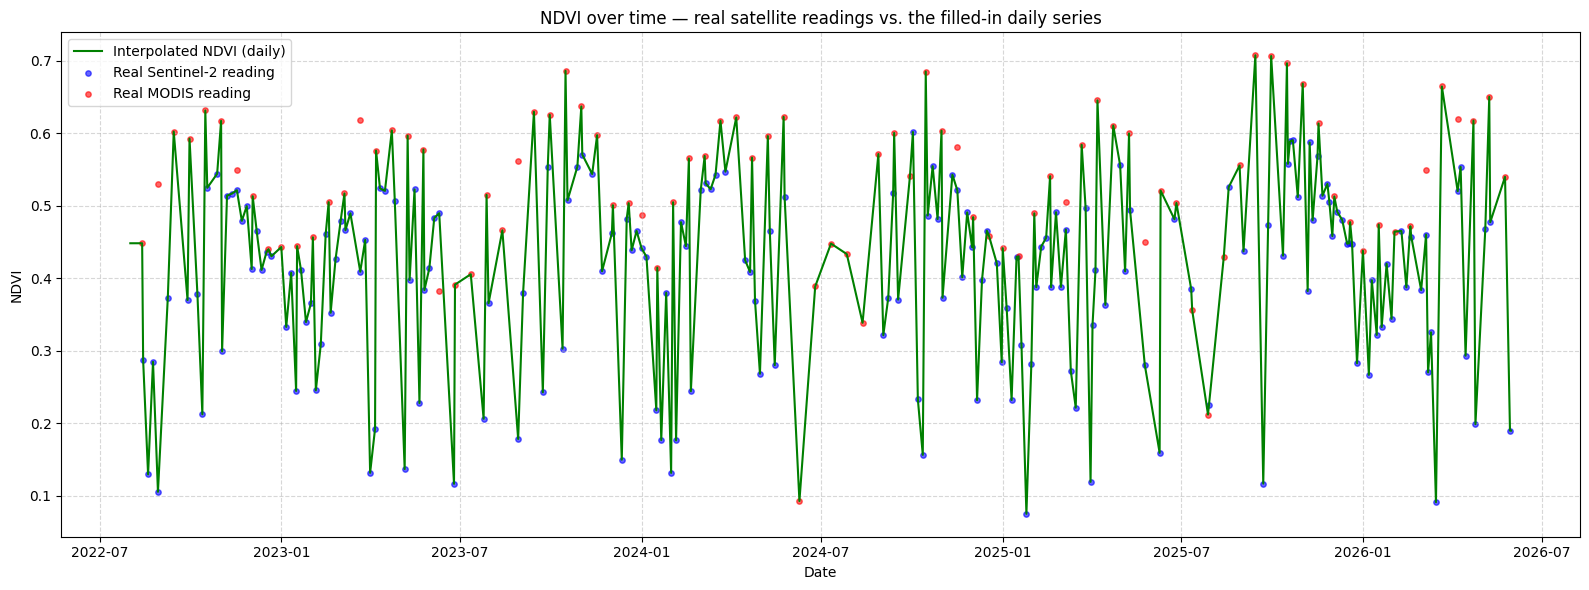

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.plot(ndvi_combined.index, ndvi_combined['NDVI_interpolated'], label='Interpolated NDVI (daily)', color='green', linewidth=1.5)
plt.scatter(s2_df.index, s2_df['NDVI_S2_raw'], label='Real Sentinel-2 reading', color='blue', s=15, alpha=0.6)
plt.scatter(modis_df.index, modis_df['NDVI_MODIS_raw'], label='Real MODIS reading', color='red', s=15, alpha=0.6)
plt.title('NDVI over time — real satellite readings vs. the filled-in daily series')
plt.xlabel('Date'); plt.ylabel('NDVI')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

## Task 4: Merge everything into a master dataset

**What this does:** joins the three data sources (air quality + weather, NASA solar/soil, NDVI) into one table, one row per day, and cleans up gaps.

In [ ]:
df_aqi_weather = pd.read_csv('sylhet_aqi_weather_extended.csv', parse_dates=['date']).set_index('date')
df_nasa = pd.read_csv('sylhet_nasa_solar_soil.csv', parse_dates=['date']).set_index('date')
df_ndvi = pd.read_csv('sylhet_real_ndvi.csv', parse_dates=['date']).set_index('date')

# Each source's index should already be unique daily dates (we de-duplicated NDVI in Task 3),
# so an outer join here should NOT introduce duplicate dates. We verify that below.
master_df = df_aqi_weather.join(df_nasa, how='outer').join(df_ndvi, how='outer').sort_index()

n_dupes = master_df.index.duplicated().sum()
print(f"Duplicate dates after merge: {n_dupes} (should be 0)")
if n_dupes > 0:
    print("Unexpected duplicates found -- inspect the source files before proceeding.")
    master_df = master_df[~master_df.index.duplicated(keep='first')]

# Fill small remaining gaps in the core numeric columns via time-based interpolation
fill_cols = ['pm2_5', 'temperature_2m', 'relative_humidity_2m', 'solar_radiation', 'soil_moisture', 'NDVI_interpolated']
for col in fill_cols:
    n_na = master_df[col].isnull().sum()
    if n_na > 0:
        master_df[col] = master_df[col].interpolate(method='time', limit_direction='both')
        print(f"Interpolated {n_na} missing values in '{col}'.")

print(f"\nMaster dataset: {master_df.shape[0]} rows, {master_df.shape[1]} columns.")
master_df.to_csv('sylhet_master_dataset.csv')
print("Saved to sylhet_master_dataset.csv")
master_df.head()

Duplicate dates after merge: 0 (should be 0)
Interpolated 3 missing values in 'pm2_5'.

Master dataset: 1400 rows, 12 columns.
Saved to sylhet_master_dataset.csv


,pm2_5,pm2_5_low_coverage_flag,temperature_2m,relative_humidity_2m,temperature_2m_low_coverage_flag,relative_humidity_2m_low_coverage_flag,solar_radiation,soil_moisture,NDVI_S2_raw,NDVI_MODIS_raw,NDVI_interpolated,NDVI_source_flag
date,,,,,,,,,,,,
2022-08-01,14.850000,1,26.637500,90.250000,0,0,3.1639,0.97,NaN,NaN,0.448285,0
2022-08-02,14.850000,1,28.079167,87.791667,0,0,4.0898,0.97,NaN,NaN,0.448285,0
2022-08-03,14.850000,1,28.308333,87.833333,0,0,4.8216,0.96,NaN,NaN,0.448285,0
2022-08-04,14.850000,0,28.595833,84.958333,0,0,4.1498,0.96,NaN,NaN,0.448285,0
2022-08-05,15.820833,0,29.337500,82.958333,0,0,4.8533,0.96,NaN,NaN,0.448285,0


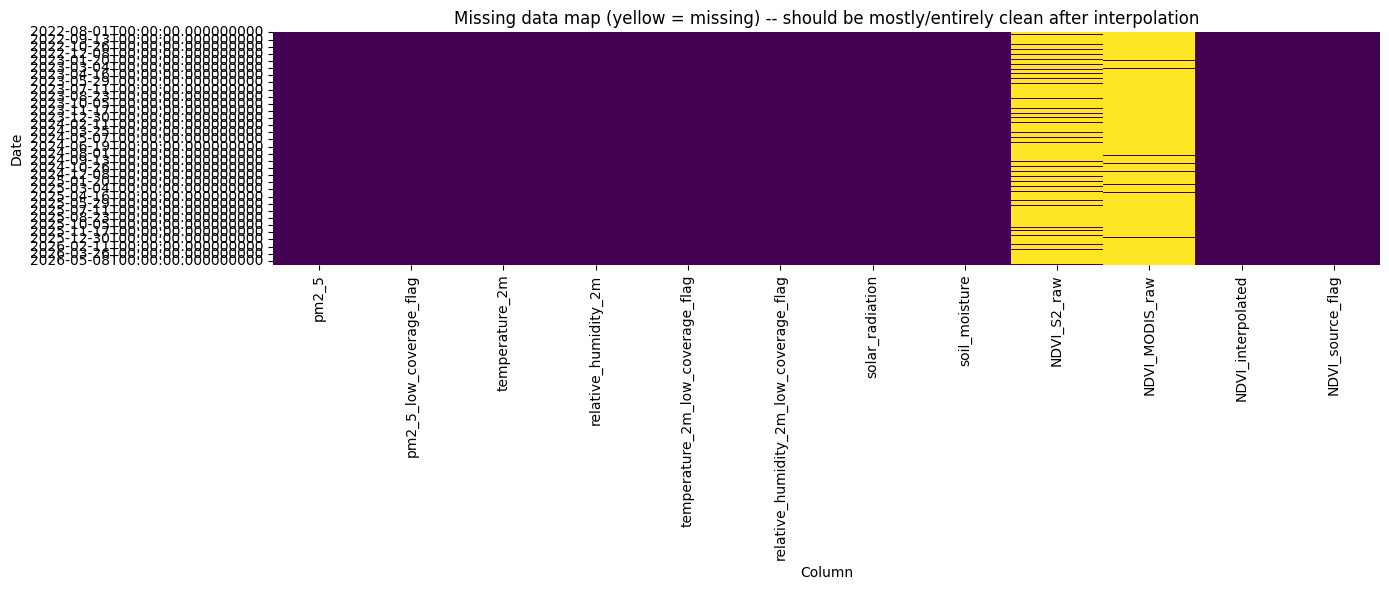

In [ ]:
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.heatmap(master_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing data map (yellow = missing) -- should be mostly/entirely clean after interpolation')
plt.xlabel('Column'); plt.ylabel('Date')
plt.tight_layout(); plt.show()

## Task 5: Exploratory Data Analysis (EDA)

Before modeling anything, we look at the data directly: what does it look like, is there seasonality, and is there any visible/statistical relationship between NDVI and PM2.5? This step is what tells us whether our hypothesis has any support *before* we build a model that might hide or distort it.

In [ ]:
key_vars = ['pm2_5', 'temperature_2m', 'relative_humidity_2m', 'solar_radiation', 'soil_moisture', 'NDVI_interpolated']
master_df[key_vars].describe()

,pm2_5,temperature_2m,relative_humidity_2m,solar_radiation,soil_moisture,NDVI_interpolated
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,40.071176,24.461857,80.653214,4.449699,0.815471,0.424756
std,21.605426,3.823913,7.390035,1.278755,0.140253,0.115126
min,0.650000,14.558333,47.833333,0.459800,0.520000,0.074811
25%,22.057292,21.323958,75.416667,3.733975,0.690000,0.357699
50%,37.222917,25.514583,81.125000,4.554200,0.830000,0.437118
75%,53.253125,27.455208,86.302083,5.355900,0.960000,0.507655
max,139.762500,32.316667,96.875000,7.360100,1.000000,0.707802


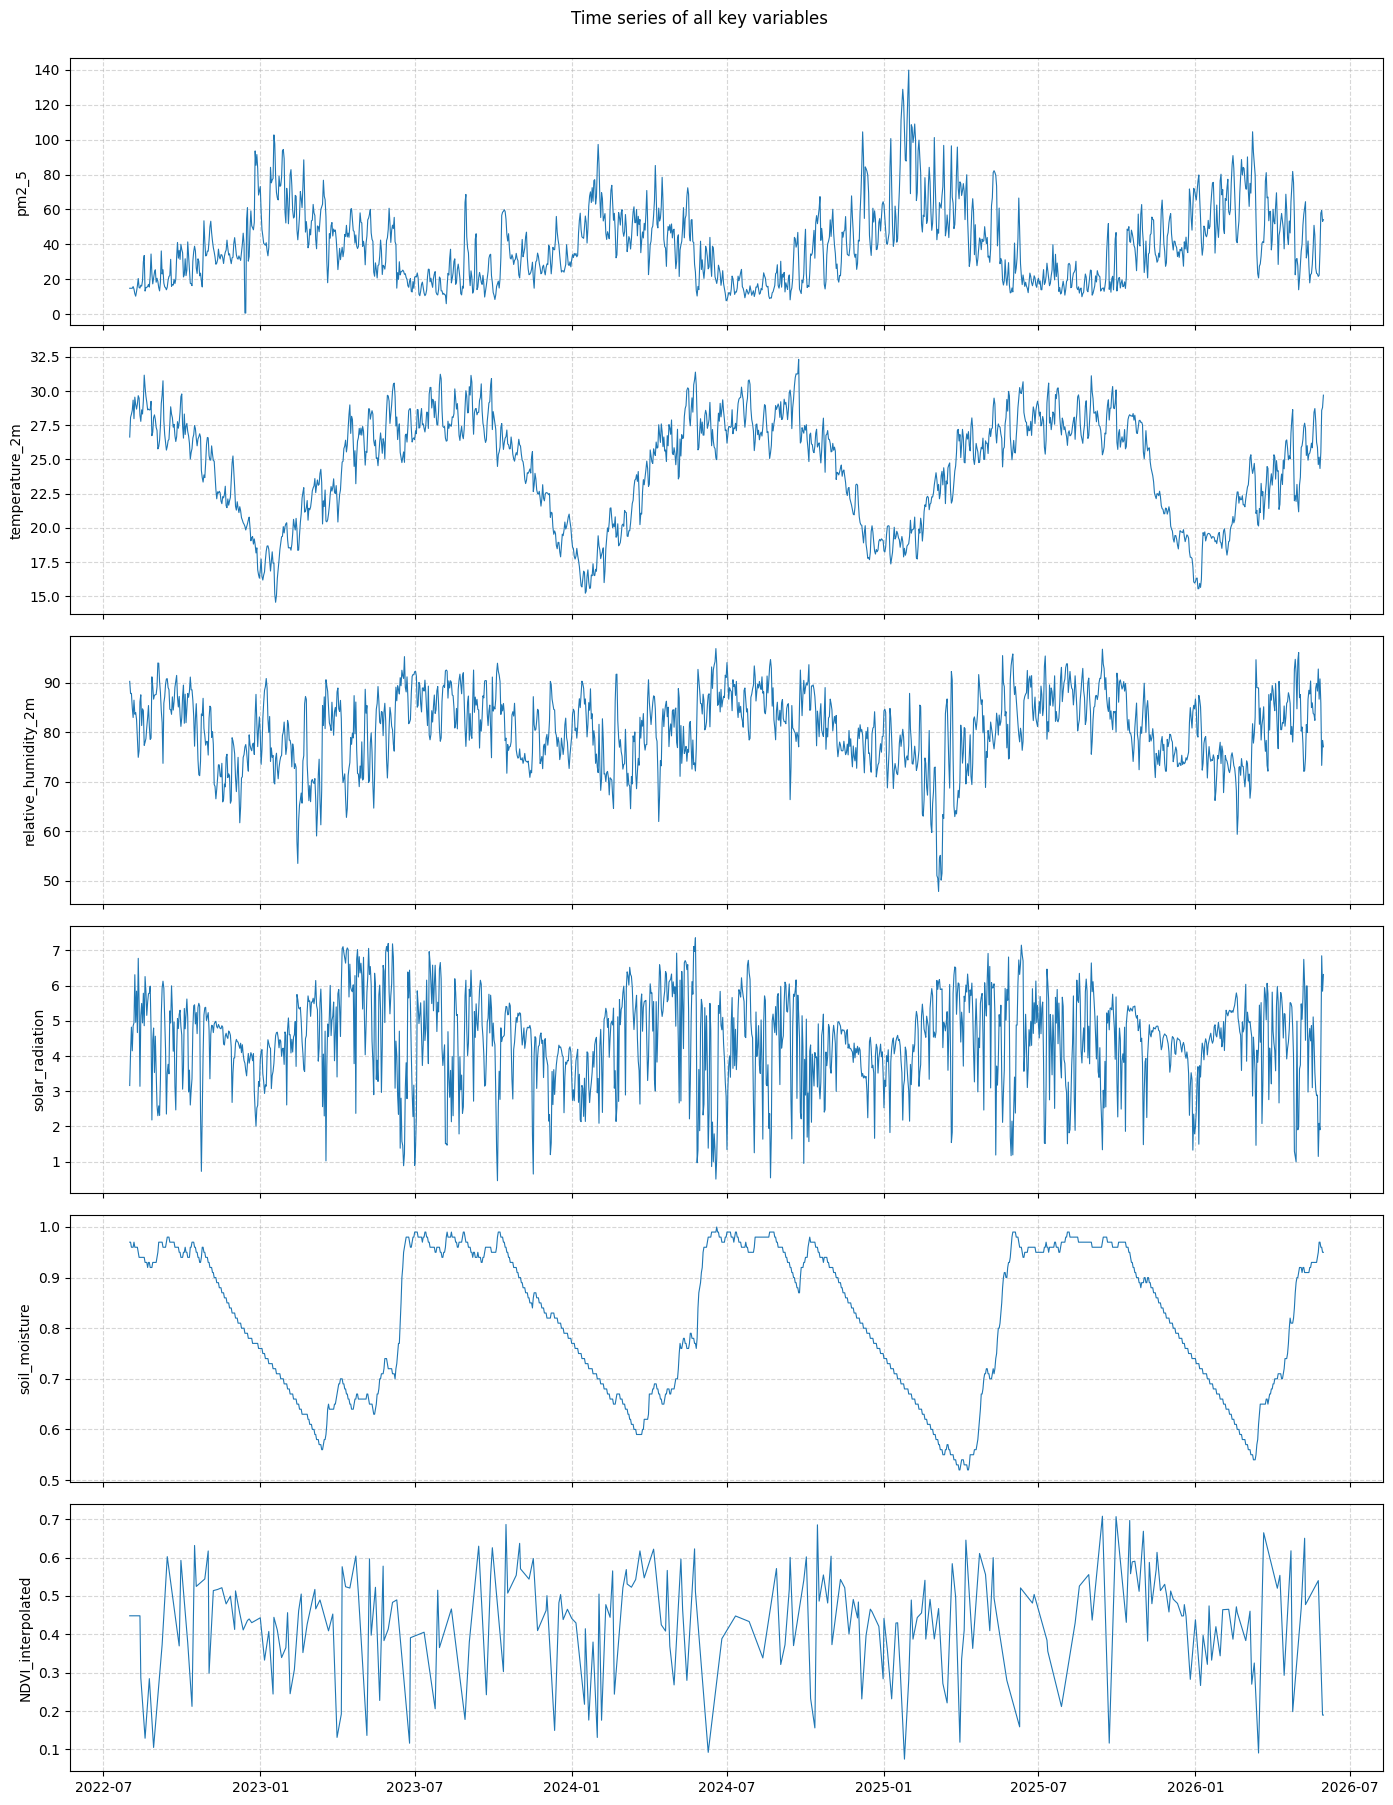

In [ ]:
fig, axes = plt.subplots(nrows=len(key_vars), ncols=1, figsize=(14, 3 * len(key_vars)), sharex=True)
for i, col in enumerate(key_vars):
    axes[i].plot(master_df.index, master_df[col], linewidth=0.8)
    axes[i].set_ylabel(col)
    axes[i].grid(True, linestyle='--', alpha=0.5)
plt.suptitle('Time series of all key variables', y=1.0)
plt.tight_layout(); plt.show()

### Correlation matrix

A quick first look: which variables move together with PM2.5? This is a **raw** correlation — it doesn't yet account for season, so treat it as a starting point, not a final answer.

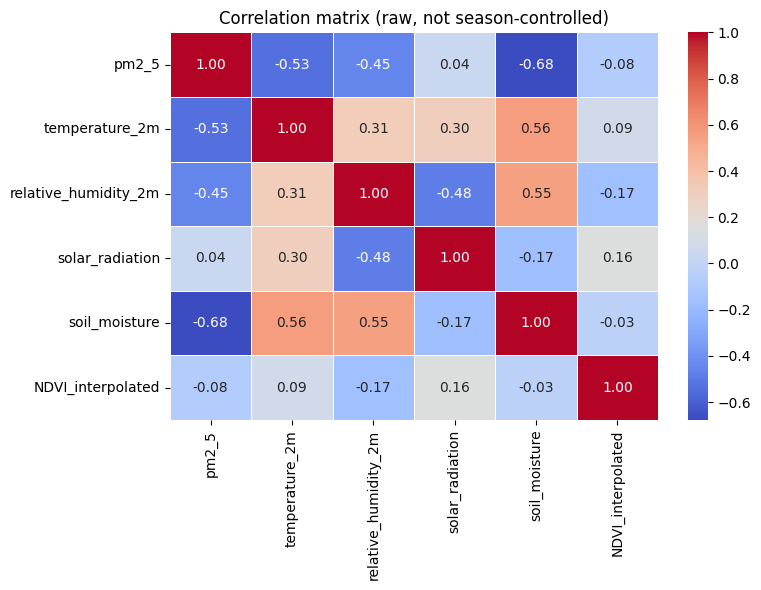

Correlation of each variable with PM2.5:
pm2_5                   1.000000
solar_radiation         0.040810
NDVI_interpolated      -0.078022
relative_humidity_2m   -0.453669
temperature_2m         -0.534054
soil_moisture          -0.677267
Name: pm2_5, dtype: float64


In [ ]:
corr_matrix = master_df[key_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation matrix (raw, not season-controlled)')
plt.tight_layout(); plt.show()

print("Correlation of each variable with PM2.5:")
print(corr_matrix['pm2_5'].sort_values(ascending=False))

### Monthly patterns — is the NDVI/PM2.5 link just both following the seasons?

Sylhet has a strong monsoon cycle. If PM2.5 and NDVI both simply follow the seasons independently (e.g., both change with rainfall, for unrelated reasons), a raw correlation between them could be **misleading** — this is called *confounding*. Looking at monthly averages helps us see this pattern directly.

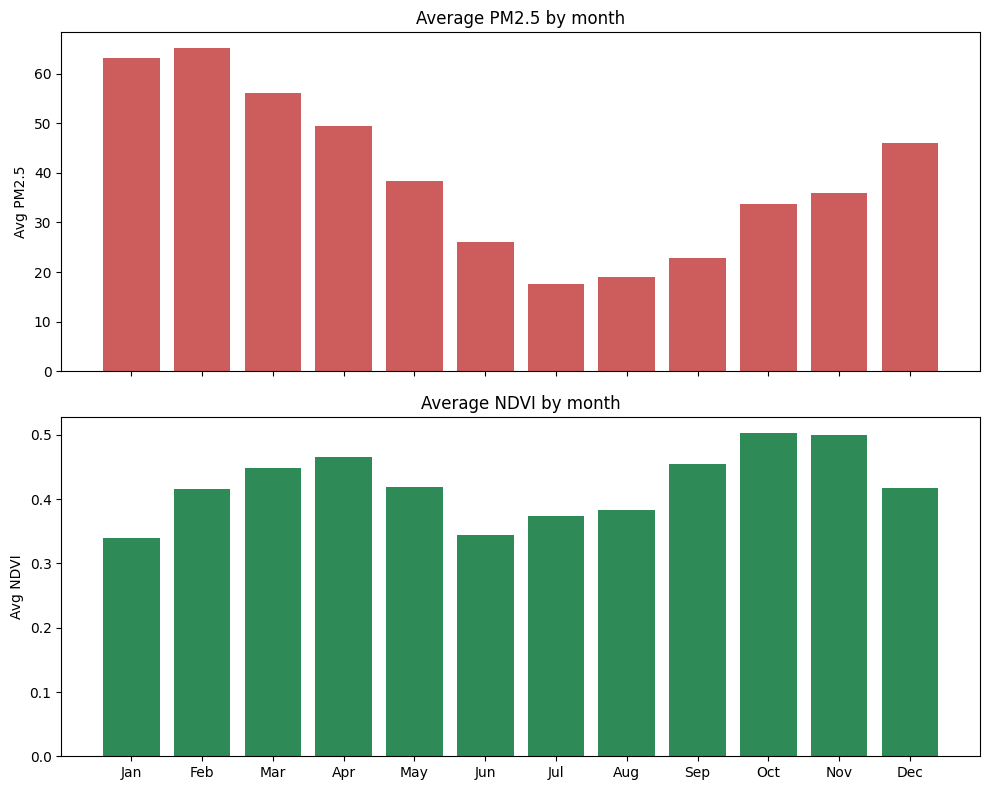

In [ ]:
master_df['month'] = master_df.index.month
monthly_avg = master_df.groupby('month')[['pm2_5', 'NDVI_interpolated']].mean()

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(monthly_avg.index, monthly_avg['pm2_5'], color='indianred')
axes[0].set_ylabel('Avg PM2.5'); axes[0].set_title('Average PM2.5 by month')
axes[1].bar(monthly_avg.index, monthly_avg['NDVI_interpolated'], color='seagreen')
axes[1].set_ylabel('Avg NDVI'); axes[1].set_title('Average NDVI by month')
axes[1].set_xticks(range(1, 13)); axes[1].set_xticklabels(month_labels)
plt.tight_layout(); plt.show()

### Scatter plot: NDVI vs PM2.5, colored by season

If the relationship holds up *within* a single season (not just across the whole year), that's much stronger evidence it isn't just both variables following the monsoon independently.

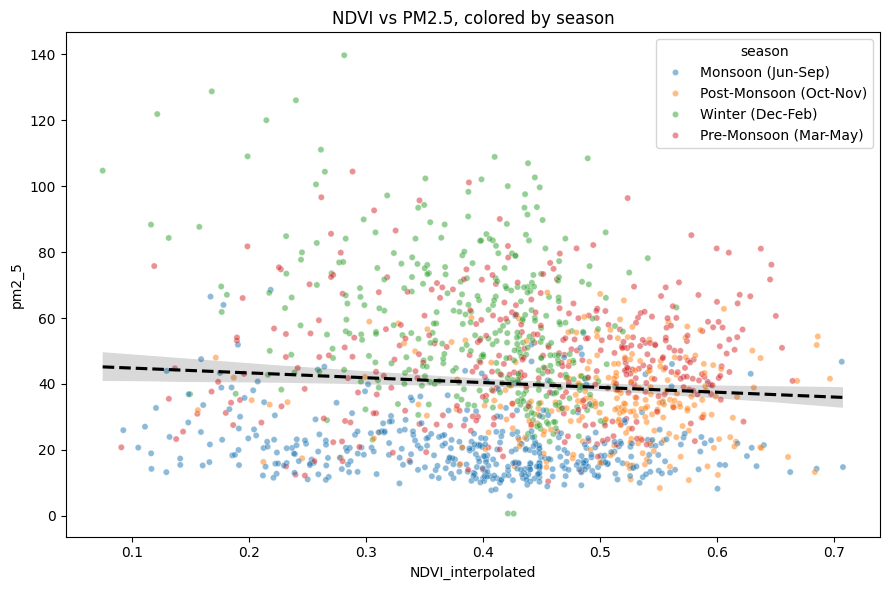

In [ ]:
master_df['season'] = master_df['month'].map({12:'Winter (Dec-Feb)', 1:'Winter (Dec-Feb)', 2:'Winter (Dec-Feb)',
                                                3:'Pre-Monsoon (Mar-May)', 4:'Pre-Monsoon (Mar-May)', 5:'Pre-Monsoon (Mar-May)',
                                                6:'Monsoon (Jun-Sep)', 7:'Monsoon (Jun-Sep)', 8:'Monsoon (Jun-Sep)', 9:'Monsoon (Jun-Sep)',
                                                10:'Post-Monsoon (Oct-Nov)', 11:'Post-Monsoon (Oct-Nov)'})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=master_df, x='NDVI_interpolated', y='pm2_5', hue='season', alpha=0.5, s=20)
sns.regplot(data=master_df, x='NDVI_interpolated', y='pm2_5', scatter=False, color='black', line_kws={'linestyle': '--'})
plt.title('NDVI vs PM2.5, colored by season')
plt.tight_layout(); plt.show()

### Statistical tests

Two questions we can now test properly instead of eyeballing:

1. **Is the NDVI decline over time statistically real, or could it be noise?** We use the **Mann-Kendall trend test**, which looks at the whole series' direction (not just the first vs. last point, which is fragile — one bad data point at either end could flip that comparison).
2. **Is the NDVI–PM2.5 correlation still significant after removing the shared seasonal pattern?** We use **partial correlation**, controlling for month.

In [ ]:
!pip install pymannkendall --quiet
import pymannkendall as mk

mk_result = mk.original_test(master_df['NDVI_interpolated'])
print("Mann-Kendall trend test on NDVI:")
print(f"  Trend direction : {mk_result.trend}")
print(f"  p-value         : {mk_result.p:.5f}")
print(f"  Significant?    : {'Yes (p < 0.05)' if mk_result.p < 0.05 else 'No (p >= 0.05)'}")
print(f"  Slope (per day) : {mk_result.slope:.6f}")

Mann-Kendall trend test on NDVI:
  Trend direction : increasing
  p-value         : 0.00564
  Significant?    : Yes (p < 0.05)
  Slope (per day) : 0.000021


In [ ]:
from scipy import stats

# Partial correlation of NDVI and PM2.5, controlling for month
# (regress each variable on month, then correlate the leftover "residuals")
def partial_correlation(df, x, y, control):
    x_resid = df[x] - df.groupby(control)[x].transform('mean')
    y_resid = df[y] - df.groupby(control)[y].transform('mean')
    r, p = stats.pearsonr(x_resid, y_resid)
    return r, p

r_raw, p_raw = stats.pearsonr(master_df['NDVI_interpolated'], master_df['pm2_5'])
r_partial, p_partial = partial_correlation(master_df, 'NDVI_interpolated', 'pm2_5', 'month')

print(f"Raw correlation (NDVI vs PM2.5):              r = {r_raw:.3f}, p = {p_raw:.5f}")
print(f"Correlation controlling for month:            r = {r_partial:.3f}, p = {p_partial:.5f}")
print()
print("If the partial-correlation r is similar to the raw r, the relationship holds up beyond season.")
print("If it shrinks a lot or loses significance, season was likely driving most of the raw correlation.")

Raw correlation (NDVI vs PM2.5):              r = -0.078, p = 0.00349
Correlation controlling for month:            r = -0.116, p = 0.00001

If the partial-correlation r is similar to the raw r, the relationship holds up beyond season.
If it shrinks a lot or loses significance, season was likely driving most of the raw correlation.


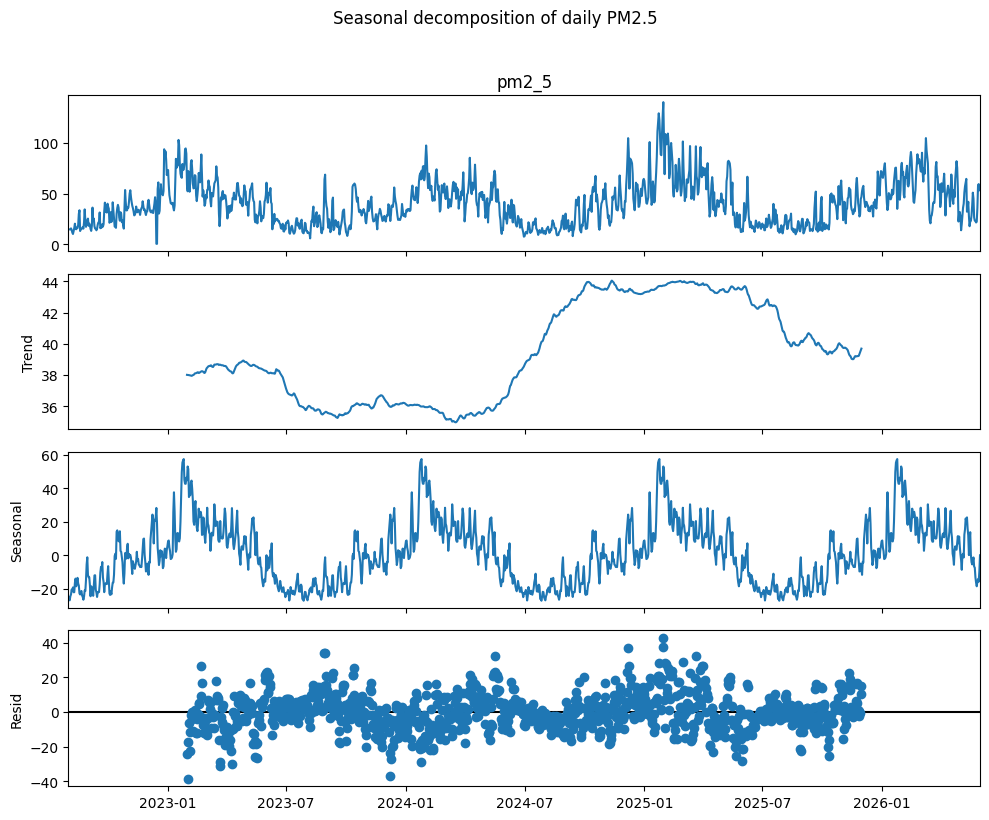

In [ ]:
import statsmodels.api as sm

pm2_5_series = master_df['pm2_5'].dropna()
decomposition = sm.tsa.seasonal_decompose(pm2_5_series, model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(10, 8)
fig.suptitle('Seasonal decomposition of daily PM2.5', y=1.02)
plt.tight_layout(); plt.show()

## Task 6: Feature Engineering

We now build extra input columns (features) that give the model more useful context than the raw daily values alone.

**A leakage warning worth understanding up front:** a "feature" is only valid if it only uses information that would actually be available *before* the day we're predicting. A rolling average that accidentally includes *today's* PM2.5 while trying to predict *today's* PM2.5 is like handing the model the answer sheet. We avoid this below by always `.shift(1)`-ing the target before computing anything rolling from it.

In [ ]:
master_df = pd.read_csv('sylhet_master_dataset.csv', parse_dates=['date']).set_index('date').sort_index()

# --- Lag features: yesterday's / recent past values ---
for i in [1, 2, 3]:
    master_df[f'pm2_5_lag_{i}'] = master_df['pm2_5'].shift(i)
    master_df[f'NDVI_interpolated_lag_{i}'] = master_df['NDVI_interpolated'].shift(i)
    master_df[f'temperature_2m_lag_{i}'] = master_df['temperature_2m'].shift(i)

# --- Longer NDVI lags, since vegetation effects on air aren't instant ---
for i in [7, 14, 30]:
    master_df[f'NDVI_interpolated_lag_{i}'] = master_df['NDVI_interpolated'].shift(i)

# --- Rolling averages -- ALWAYS shift(1) first so "today" is never included ---
master_df['pm2_5_rolling_mean_7D'] = master_df['pm2_5'].shift(1).rolling(window=7).mean()
master_df['pm2_5_rolling_mean_30D'] = master_df['pm2_5'].shift(1).rolling(window=30).mean()
# NDVI is an input feature, not the target, so it's fine to use its own current+past values directly
master_df['NDVI_interpolated_rolling_mean_7D'] = master_df['NDVI_interpolated'].rolling(window=7).mean()

# --- Calendar / seasonal features ---
master_df['month'] = master_df.index.month
master_df['day_of_week'] = master_df.index.dayofweek
master_df['day_of_year'] = master_df.index.dayofyear
master_df['is_weekend'] = master_df['day_of_week'].isin([5, 6]).astype(int)
# Cyclic encoding so the model knows Dec 31 and Jan 1 are adjacent, not far apart
master_df['month_sin'] = np.sin(2 * np.pi * master_df['month'] / 12)
master_df['month_cos'] = np.cos(2 * np.pi * master_df['month'] / 12)
# Monsoon indicator: Sylhet's monsoon runs roughly June-September
master_df['is_monsoon'] = master_df['month'].isin([6, 7, 8, 9]).astype(int)

# --- Interaction feature: NDVI x soil moisture (vegetation tends to track soil water) ---
master_df['ndvi_soil_moisture_interaction'] = master_df['NDVI_interpolated'] * master_df['soil_moisture']

print(f"Feature engineering complete. Dataset now has {master_df.shape[1]} columns.")
master_df.to_csv('sylhet_master_dataset_features.csv')
master_df.tail()

Feature engineering complete. Dataset now has 35 columns.


,pm2_5,pm2_5_low_coverage_flag,temperature_2m,relative_humidity_2m,temperature_2m_low_coverage_flag,relative_humidity_2m_low_coverage_flag,solar_radiation,soil_moisture,NDVI_S2_raw,NDVI_MODIS_raw,...,pm2_5_rolling_mean_30D,NDVI_interpolated_rolling_mean_7D,month,day_of_week,day_of_year,is_weekend,month_sin,month_cos,is_monsoon,ndvi_soil_moisture_interaction
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27,36.108333,0,24.337500,90.750000,0,0,1.9063,0.97,NaN,NaN,...,34.014167,0.504000,5,2,147,0,0.5,-0.866025,0,0.387851
2026-05-28,57.920833,0,25.529167,85.875000,0,0,4.1100,0.96,NaN,NaN,...,33.372917,0.476353,5,3,148,0,0.5,-0.866025,0,0.316580
2026-05-29,59.345833,0,28.591667,73.291667,0,0,6.8486,0.96,NaN,NaN,...,34.551250,0.438100,5,4,149,0,0.5,-0.866025,0,0.249307
2026-05-30,53.125000,0,28.800000,78.333333,0,0,5.8423,0.95,0.18962,NaN,...,35.492361,0.389239,5,5,150,1,0.5,-0.866025,0,0.180139
2026-05-31,54.112500,0,29.700000,77.041667,0,0,6.3170,0.95,NaN,NaN,...,36.200278,0.339781,5,6,151,1,0.5,-0.866025,0,0.180139


## Task 7: Modeling — predicting PM2.5

**What we're testing:** does adding NDVI (vegetation) features actually improve how well we can predict PM2.5, beyond what weather alone tells us? That's the direct test of our research question.

**Two rules we follow carefully, because this is time-series data:**
1. **Split by date, not randomly.** We train on the earlier period and test on a later, unseen period — like a real forecasting situation. Randomly shuffling rows would let the model "peek" at the future.
2. **Fit any preprocessing (like scaling) only on the training data.** If we calculate the average/spread of a feature using the test period too, that's data leakage — the model gets an unfair hint about data it's not supposed to have seen yet.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    !pip install xgboost --quiet
    from xgboost import XGBRegressor
    HAS_XGB = True

master_df = pd.read_csv('sylhet_master_dataset_features.csv', parse_dates=['date']).set_index('date').sort_index()

# Drop columns that shouldn't be model inputs: coverage/flag columns, raw NDVI source columns
# (we use the interpolated NDVI and its engineered features instead), and anything computed
# directly from today's PM2.5 without a lag (that would be leakage).
drop_cols = [c for c in master_df.columns if 'coverage' in c or 'low_coverage_flag' in c]
drop_cols += ['NDVI_S2_raw', 'NDVI_MODIS_raw', 'NDVI_source_flag', 'season']
drop_cols = [c for c in drop_cols if c in master_df.columns]

model_df = master_df.drop(columns=drop_cols).dropna()
print(f"Rows available for modeling after dropping NaNs (from lag/rolling features): {len(model_df)}")

TARGET = 'pm2_5'
TRAIN_SPLIT_DATE = '2025-01-01'

X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

# --- Split FIRST, by date ---
X_train, X_test = X[X.index < TRAIN_SPLIT_DATE], X[X.index >= TRAIN_SPLIT_DATE]
y_train, y_test = y[y.index < TRAIN_SPLIT_DATE], y[y.index >= TRAIN_SPLIT_DATE]
print(f"Train: {X_train.index.min().date()} to {X_train.index.max().date()} ({len(X_train)} rows)")
print(f"Test:  {X_test.index.min().date()} to {X_test.index.max().date()} ({len(X_test)} rows)")

# --- THEN scale, fitting only on the training set ---
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])   # fit on TRAIN only
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])        # apply (don't refit) on TEST
print("Scaled: scaler was fit on the training set only, then applied to the test set.")

Rows available for modeling after dropping NaNs (from lag/rolling features): 1370
Train: 2022-08-31 to 2024-12-31 (854 rows)
Test:  2025-01-01 to 2026-05-31 (516 rows)
Scaled: scaler was fit on the training set only, then applied to the test set.


### Compare three models

We try a simple, interpretable model (Linear Regression) alongside two more flexible ones (Random Forest, XGBoost). For cross-validation during tuning, we use **TimeSeriesSplit**, which respects time order — unlike normal k-fold, which would again let the model peek at the future.

In [ ]:
def evaluate(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

tscv = TimeSeriesSplit(n_splits=5)
results = {}

# --- Linear Regression (baseline, interpretable) ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
results['Linear Regression'] = evaluate(y_test, lr.predict(X_test_scaled))

# --- Random Forest, tuned ---
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_param_grid,
                                n_iter=10, cv=tscv, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)
rf_search.fit(X_train_scaled, y_train)
best_rf = rf_search.best_estimator_
results['Random Forest'] = evaluate(y_test, best_rf.predict(X_test_scaled))

# --- XGBoost, tuned ---
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}
xgb_search = RandomizedSearchCV(XGBRegressor(random_state=42, n_jobs=-1), xgb_param_grid,
                                 n_iter=10, cv=tscv, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)
xgb_search.fit(X_train_scaled, y_train)
best_xgb = xgb_search.best_estimator_
results['XGBoost'] = evaluate(y_test, best_xgb.predict(X_test_scaled))

results_df = pd.DataFrame(results).T
print("Model comparison on the held-out test set (lower MAE/RMSE better, higher R2 better):")
results_df

Model comparison on the held-out test set (lower MAE/RMSE better, higher R2 better):


,MAE,RMSE,R2
Linear Regression,7.788196,10.359615,0.822289
Random Forest,8.589615,11.781512,0.770158
XGBoost,8.580389,11.840497,0.767851


### The key test: does removing NDVI hurt performance?

This is the direct answer to our research question. We take the best-performing model's settings and train it twice: once with all features (including NDVI), and once with every NDVI-related column removed. If NDVI is genuinely useful, removing it should make predictions noticeably worse.

In [ ]:
best_model_name = results_df['RMSE'].idxmin()
print(f"Best model on test RMSE: {best_model_name}")

ndvi_cols = [c for c in X.columns if 'NDVI' in c or 'ndvi' in c]
print(f"Dropping these NDVI-related columns for the comparison: {ndvi_cols}")

X_train_no_ndvi = X_train_scaled.drop(columns=ndvi_cols)
X_test_no_ndvi = X_test_scaled.drop(columns=ndvi_cols)

if best_model_name == 'Linear Regression':
    model_with = LinearRegression().fit(X_train_scaled, y_train)
    model_without = LinearRegression().fit(X_train_no_ndvi, y_train)
elif best_model_name == 'Random Forest':
    model_with = best_rf
    model_without = RandomForestRegressor(**rf_search.best_params_, random_state=42, n_jobs=-1).fit(X_train_no_ndvi, y_train)
else:
    model_with = best_xgb
    model_without = XGBRegressor(**xgb_search.best_params_, random_state=42, n_jobs=-1).fit(X_train_no_ndvi, y_train)

metrics_with = evaluate(y_test, model_with.predict(X_test_scaled))
metrics_without = evaluate(y_test, model_without.predict(X_test_no_ndvi))

comparison = pd.DataFrame({'With NDVI features': metrics_with, 'Without NDVI features': metrics_without})
comparison['Difference (with - without)'] = comparison['With NDVI features'] - comparison['Without NDVI features']
print(f"\n--- {best_model_name}: with vs. without NDVI ---")
comparison

Best model on test RMSE: Linear Regression
Dropping these NDVI-related columns for the comparison: ['NDVI_interpolated', 'NDVI_interpolated_lag_1', 'NDVI_interpolated_lag_2', 'NDVI_interpolated_lag_3', 'NDVI_interpolated_lag_7', 'NDVI_interpolated_lag_14', 'NDVI_interpolated_lag_30', 'NDVI_interpolated_rolling_mean_7D', 'ndvi_soil_moisture_interaction']

--- Linear Regression: with vs. without NDVI ---


,With NDVI features,Without NDVI features,Difference (with - without)
MAE,7.788196,7.729215,0.058981
RMSE,10.359615,10.337383,0.022232
R2,0.822289,0.823051,-0.000762


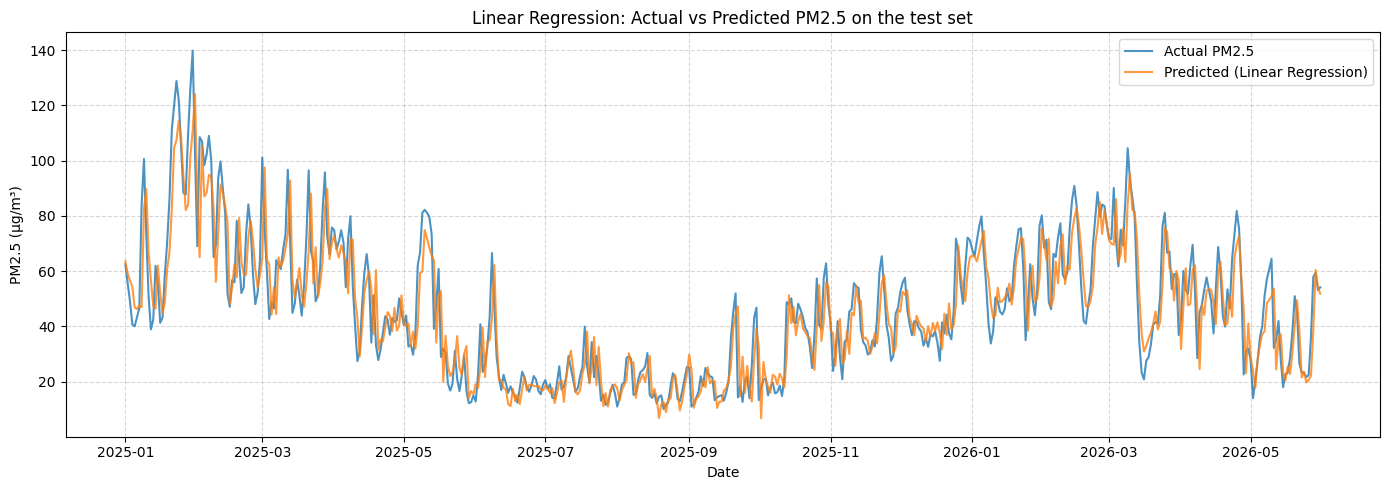

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label='Actual PM2.5', alpha=0.8)
plt.plot(y_test.index, model_with.predict(X_test_scaled), label=f'Predicted ({best_model_name})', alpha=0.8)
plt.title(f'{best_model_name}: Actual vs Predicted PM2.5 on the test set')
plt.xlabel('Date'); plt.ylabel('PM2.5 (µg/m³)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

## Task 8: Interpretability

A model that predicts well is only half the story for a research paper — we also need to explain *why*, in a way a reader can trust. We use **SHAP**, which shows both how important a feature is and which direction it pushes predictions (does more NDVI push PM2.5 up or down?).

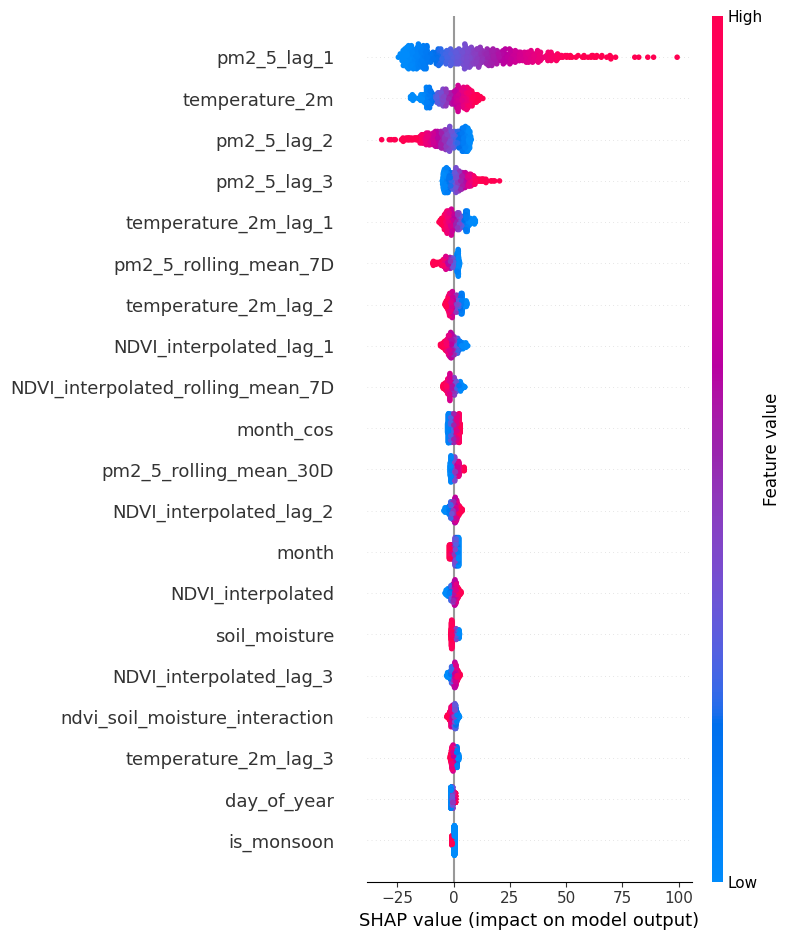

In [ ]:
!pip install shap --quiet
import shap

explainer = shap.TreeExplainer(model_with) if best_model_name != 'Linear Regression' else shap.LinearExplainer(model_with, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.tight_layout(); plt.show()

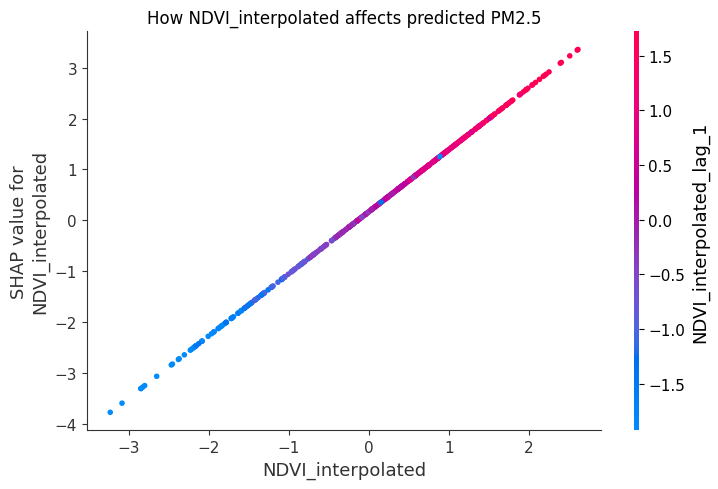

In [ ]:
# Zoom in on NDVI specifically -- this is the plot that most directly answers our research question
ndvi_feature_to_plot = 'NDVI_interpolated' if 'NDVI_interpolated' in X_test_scaled.columns else ndvi_cols[0]
shap.dependence_plot(ndvi_feature_to_plot, shap_values, X_test_scaled, show=False)
plt.title(f'How {ndvi_feature_to_plot} affects predicted PM2.5')
plt.tight_layout(); plt.show()

In [ ]:
# Simple, interpretable cross-check: Linear Regression coefficients
lr_full = LinearRegression().fit(X_train_scaled, y_train)
coef_df = pd.Series(lr_full.coef_, index=X_train_scaled.columns).sort_values(key=abs, ascending=False)
print("Linear Regression coefficients (larger magnitude = bigger linear effect on PM2.5):")
coef_df.head(15)

Linear Regression coefficients (larger magnitude = bigger linear effect on PM2.5):


,0
pm2_5_lag_1,17.899383
temperature_2m,7.983238
pm2_5_lag_2,-5.750314
temperature_2m_lag_1,-4.015113
pm2_5_lag_3,3.674922
temperature_2m_lag_2,-2.441703
NDVI_interpolated_lag_1,-2.082438
pm2_5_rolling_mean_7D,-2.017071
month_cos,1.916383
NDVI_interpolated_rolling_mean_7D,-1.843492


## Task 9: Research-Paper-Ready Summary

This section pulls together the honest headline results — including the ones that don't flatter the original hypothesis, since a paper needs to report what the data actually showed, not just what we hoped to find.

In [ ]:
print("=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print(f"""
Research question: Does vegetation cover (NDVI) help explain/predict
PM2.5 air pollution in Sylhet, Bangladesh ({START_DATE} to {END_DATE}),
once weather and seasonality are accounted for?

--- NDVI trend ---
Mann-Kendall test: {mk_result.trend}, p = {mk_result.p:.5f}
({'a statistically significant trend' if mk_result.p < 0.05 else 'NOT statistically significant -- interpret any visual decline with caution'})

--- Raw relationship ---
Correlation (NDVI vs PM2.5): r = {r_raw:.3f} (p = {p_raw:.5f})
Correlation controlling for month: r = {r_partial:.3f} (p = {p_partial:.5f})
""")

print("--- Best model performance (with all features) ---")
print(results_df.loc[[best_model_name]])

print(f"\n--- Does NDVI actually help prediction? ({best_model_name}) ---")
print(comparison)

if comparison.loc['R2', 'Difference (with - without)'] > 0.01:
    print("\n--> NDVI features provided a meaningful improvement in predicting PM2.5.")
else:
    print("\n--> NDVI features provided little to no measurable improvement in predicting PM2.5")
    print("    in this dataset. This is a legitimate, reportable finding -- it may reflect a genuinely")
    print("    weak local relationship, insufficient NDVI data quality/resolution, or a relationship")
    print("    that operates on a timescale or spatial scale this data doesn't capture well.")

PROJECT SUMMARY

Research question: Does vegetation cover (NDVI) help explain/predict
PM2.5 air pollution in Sylhet, Bangladesh (2022-08-01 to 2026-05-31),
once weather and seasonality are accounted for?

--- NDVI trend ---
Mann-Kendall test: increasing, p = 0.00564
(a statistically significant trend)

--- Raw relationship ---
Correlation (NDVI vs PM2.5): r = -0.078 (p = 0.00349)
Correlation controlling for month: r = -0.116 (p = 0.00001)

--- Best model performance (with all features) ---
                        MAE       RMSE        R2
Linear Regression  7.788196  10.359615  0.822289

--- Does NDVI actually help prediction? (Linear Regression) ---
      With NDVI features  Without NDVI features  Difference (with - without)
MAE             7.788196               7.729215                     0.058981
RMSE           10.359615              10.337383                     0.022232
R2              0.822289               0.823051                    -0.000762

--> NDVI features provided little

### Limitations (include this section in the paper)

- **Single city, single time period.** Findings describe Sylhet 2022–2026 and shouldn't be generalized elsewhere without further testing.
- **NDVI data gaps.** A meaningful share of daily NDVI values are interpolated rather than direct satellite readings, due to cloud cover (see the real-vs-interpolated ratio printed in Task 3). This smooths the true day-to-day variability.
- **Correlation/prediction ≠ causation.** Even a strong statistical relationship doesn't prove tree loss *causes* worse air quality — both could be driven by a shared third factor we haven't measured (e.g., urban development, traffic, industrial activity).
- **Seasonal confounding.** PM2.5 and NDVI both vary strongly with the monsoon cycle. We controlled for month using partial correlation, but more rigorous causal methods (e.g., structural time-series models) could isolate this further.
- **NDVI is a proxy, not a direct tree-cover measurement.** It reflects overall greenness (which includes crops and grass, not just trees).

In [ ]:
import joblib
joblib.dump(model_with, 'sylhet_pm25_model.joblib')
joblib.dump(scaler, 'sylhet_scaler.joblib')
print("Saved final model to sylhet_pm25_model.joblib")
print("Saved fitted scaler to sylhet_scaler.joblib")

Saved final model to sylhet_pm25_model.joblib
Saved fitted scaler to sylhet_scaler.joblib


## How to explain this project in 60 seconds

*"I looked at whether tree/vegetation cover — measured by satellite as NDVI — is related to air pollution (PM2.5) in Sylhet, Bangladesh, over about four years. I pulled real satellite vegetation data from Sentinel-2 and MODIS, combined it with weather and pollution data, and built machine learning models to predict daily PM2.5. I specifically tested whether adding vegetation data improved the model's predictions compared to using weather alone, and checked whether any NDVI–PM2.5 relationship held up after accounting for Sylhet's strong monsoon season. [Fill in your actual result here once you've run the notebook: e.g., 'vegetation showed a weak/moderate/negligible relationship, largely explained by season' or 'vegetation added a measurable improvement even after controlling for season.'] The main limitation is that this is observational data from one city, so it shows association, not proof of causation."*

Fill in the bracketed part with your actual numbers once you've run the whole notebook — don't guess at the result in advance.